# Yield Model Simulator for W2W hybrid bonding
#### Author: Zhichao Chen
#### Date: Aug 25, 2025
#### Description: YAP+ (pad-layout-aware yield analysis)

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import numpy as np
from utils.util import *
import time
import matplotlib.pyplot as plt
from assembly_yield_simulator import Assembly_Yield_Simulator
from pad_bitmap_generation import pad_bitmap_generate

Random seed: 20260721 (fixed and reproducible).
Processing point 1/1...
PAD_ARR_ROW: 1000
PAD_ARR_COL: 1000
Number of pad blocks: 2500
Pad block size: 20
Number of critical pad blocks: 2500
Number of redundant pad blocks: 0
Number of dummy pad blocks: 0
Pad bitmap collections info saved.
Processing die 540/540..., Time taken for every 10 dies: 0.15 seconds
Processing wafer 1/10..., Current mean yield is 87.5883%.
Processing die 540/540..., Time taken for every 10 dies: 0.00 seconds
Processing wafer 2/10..., Current mean yield is 87.8661%.
Processing die 540/540..., Time taken for every 10 dies: 0.00 seconds
Processing wafer 3/10..., Current mean yield is 88.0204%.
Processing die 540/540..., Time taken for every 10 dies: 0.00 seconds
Processing wafer 4/10..., Current mean yield is 88.1901%.
Processing die 540/540..., Time taken for every 10 dies: 0.00 seconds
Processing wafer 5/10..., Current mean yield is 88.3290%.
Processing die 540/540..., Time taken for every 10 dies: 0.01 seconds
P

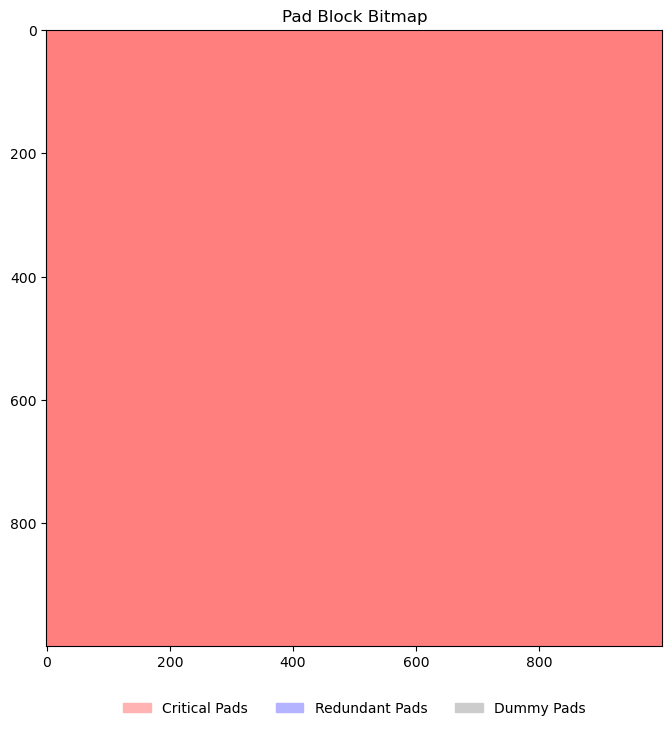

In [5]:
# Load configuration
cfg = load_modeling_config(path='configs/config.yaml', 
                     mode='w2w_simulation',
                     debug=False)
num_points = 1      # Increase only when at least one sweep range varies
# Explore the impact of all factors on the assembly yield
die_size_list = np.linspace(1e4, 1e4, num_points)
PITCH_um_list = np.linspace(10, 10, num_points)
particle_density_list = np.logspace(-9, -9, num_points)
t_0_list = np.linspace(0.1, 0.1, num_points)
dish_std_list = np.linspace(1, 1, num_points)
translation_list = np.linspace(0, 0, num_points)
rotation_mean_list = np.linspace(5e-8, 5e-8, num_points)
Roughness_sigma_m_list = np.linspace(1.0e-9, 1.0e-9, num_points)
PAD_BOT_R_um_ratio_list = np.linspace(0.5, 0.5, num_points)
PAD_TOP_R_um_ratio_list = np.linspace(2/3, 2/3, num_points)
BOW_DIFFERENCE_MEAN_um_list = np.linspace(0.5, 0.5, num_points)

assembly_yield_list = []
replica_spacing_um = 800.0  # Physical main-to-replica block spacing
pad_bitmap_collection = None
previous_layout_key = None

cfg.NUM_WAFERS = 10
single_config_yield_list_array = np.zeros([len(particle_density_list), cfg.simulation_times * cfg.NUM_WAFERS])
start_time = time.time()
for i in range(num_points):
    print("Processing point {}/{}...".format(i + 1, num_points))
    # Update parameters
    cfg.DIE_W_um = float(die_size_list[i])  # die width (um)
    cfg.DIE_L_um = float(die_size_list[i])  # die length (um)
    cfg.PITCH_um = float(PITCH_um_list[i])  # PITCH_um (um)
    cfg.PAD_TOP_R_um_ratio = float(PAD_TOP_R_um_ratio_list[i])  # top Cu pad radius ratio
    cfg.PAD_BOT_R_um_ratio = float(PAD_BOT_R_um_ratio_list[i])  # bottom Cu pad radius ratio
    cfg.SYSTEM_TRANSLATION_X_MEAN_um = float(translation_list[i])  # systematic translation mean (um) - x direction
    cfg.SYSTEM_TRANSLATION_Y_MEAN_um = float(translation_list[i])  # systematic translation mean (um) - y direction
    cfg.SYSTEM_ROTATION_MEAN_rad = float(rotation_mean_list[i])  # systematic rotation mean (rad)
    cfg.D0 = float(particle_density_list[i])  # particle density (um^{-2})
    cfg.t_0 = float(t_0_list[i])  # smallest particle thickness (um)
    cfg.BOW_DIFFERENCE_MEAN_um = float(BOW_DIFFERENCE_MEAN_um_list[i])  # bow difference mean (um)
    cfg.TOP_DISH_STD_nm = float(dish_std_list[i])  # Top Cu pad dish standard deviation (nm)
    cfg.BOT_DISH_STD_nm = float(dish_std_list[i])  # Bottom Cu pad dish standard deviation (nm)
    cfg.Roughness_sigma_m = float(Roughness_sigma_m_list[i])  # Surface roughness standard deviation (m)
    cfg.redundant_logical_pad_dist = replica_spacing_um / cfg.PITCH_um
    # Update above parameters in the configuration
    update_config_items(cfg=cfg, mode='w2w_simulation')

    # Rebuild only when a parameter that determines the pad layout changes.
    layout_key = (
        cfg.PAD_ARR_ROW, cfg.PAD_ARR_COL, cfg.pad_block_size,
        cfg.critical_pad_ratio, cfg.redundant_pad_ratio,
        cfg.redundant_logical_pad_ratio, cfg.redundant_logical_pad_copy,
        cfg.redundant_logical_pad_dist, cfg.redundant_block_interval,
    )
    if layout_key != previous_layout_key:
        pad_bitmap_collection = pad_bitmap_generate(cfg=cfg, pad_layout_pattern='center')
        previous_layout_key = layout_key

    assembly_yield, single_config_yield_list = Assembly_Yield_Simulator(
        cfg=cfg,
        pad_bitmap_collection=pad_bitmap_collection,                                    
    )
                                                                        
    assembly_yield_list.append(assembly_yield)
    single_config_yield_list_array[i] = np.array(single_config_yield_list).flatten()
print("Total time taken: {:.2f} seconds".format(time.time() - start_time))